https://drive.google.com/drive/folders/1E6AxiyPXiEd8kzJGG1XFUp9PrMnyFj1Y?usp=sharing

# I. Import Libraries

In [37]:
import warnings
import os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [38]:
tf.random.set_seed(42)
np.random.seed(42)

# II. Exploratory Data Analysis

In [39]:
df = pd.read_parquet('1A.parquet')
df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,yield
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,None,...,2024-01-08,2024-05-09,122,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild,44080.7
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,SENS0002,2024-04-21,16.613022,70.869009,0.58,None,53899.8
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild,29311.6
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,SENS0004,2024-05-14,31.071298,85.519998,0.44,None,42278.0
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,None,...,2024-02-05,2024-05-20,105,SENS0005,2024-04-13,16.56854,81.691720,0.84,Severe,49799.6


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   farm_id              500 non-null    object 
 1   region               500 non-null    object 
 2   crop_type            500 non-null    object 
 3   soil_moisture_%      500 non-null    float64
 4   soil_pH              500 non-null    object 
 5   temperature_C        500 non-null    float64
 6   rainfall_mm          500 non-null    float64
 7   humidity_%           500 non-null    float64
 8   sunlight_hours       499 non-null    float64
 9   irrigation_type      350 non-null    object 
 10  fertilizer_type      500 non-null    object 
 11  pesticide_usage_ml   500 non-null    float64
 12  sowing_date          500 non-null    object 
 13  harvest_date         500 non-null    object 
 14  total_days           500 non-null    int64  
 15  sensor_id            500 non-null    obj

In [41]:
df.describe()

,soil_moisture_%,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,longitude,NDVI_index,yield
count,500.000000,500.000000,500.000000,500.000000,499.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,26.750140,24.675740,181.685740,65.194460,7.031904,26.586980,119.114000,80.392248,0.602060,40329.269400
std,10.150053,5.348899,72.293091,14.642849,1.692908,13.202429,18.403107,5.910664,0.175402,11744.330399
min,10.160000,15.000000,50.170000,40.230000,4.010000,5.050000,-50.000000,70.020021,0.300000,20235.600000
25%,17.890000,20.295000,119.217500,51.865000,5.665000,14.945000,105.000000,75.374713,0.447500,29948.200000
50%,25.855000,24.655000,191.545000,65.685000,7.000000,25.980000,118.500000,80.650284,0.610000,40716.900000
75%,36.022500,29.090000,239.035000,77.995000,8.470000,38.005000,134.000000,85.654629,0.750000,50621.100000
max,44.980000,34.840000,298.960000,90.000000,10.000000,49.940000,150.000000,89.991901,0.900000,59982.900000


In [42]:
df.isna().sum()

,0
farm_id,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,1
irrigation_type,150


In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
for col in df.select_dtypes('object').columns:
    print(f'\nColumn: {col}')
    print(df[col].value_counts(dropna=False))


Column: farm_id
farm_id
FARM0500    1
FARM0001    1
FARM0002    1
FARM0003    1
FARM0484    1
           ..
FARM0009    1
FARM0008    1
FARM0007    1
FARM0006    1
FARM0005    1
Name: count, Length: 500, dtype: int64

Column: region
region
Central USA    109
East Africa    107
North India     99
South USA       94
South India     91
Name: count, dtype: int64

Column: crop_type
crop_type
Maize      111
Soybean    108
Cotton     107
Wheat       92
Rice        82
Name: count, dtype: int64

Column: soil_pH
soil_pH
5.97    7
6.33    7
7.3     6
6.78    6
6.3     6
       ..
6.47    1
6,42    1
7.08    1
5.82    1
6.71    1
Name: count, Length: 186, dtype: int64

Column: irrigation_type
irrigation_type
None         150
Sprinkler    121
Manual       118
Drip         111
Name: count, dtype: int64

Column: fertilizer_type
fertilizer_type
Inorganic    167
Mixed        167
Organic      166
Name: count, dtype: int64

Column: sowing_date
sowing_date
2024-03-05    15
2024-03-07    11
2024-02-02    

In [45]:
for col in df.select_dtypes('object').columns:
    print(f'{col:25s}: {df[col].nunique()} unique values')

farm_id                  : 500 unique values
region                   : 5 unique values
crop_type                : 5 unique values
soil_pH                  : 186 unique values
irrigation_type          : 3 unique values
fertilizer_type          : 3 unique values
sowing_date              : 84 unique values
harvest_date             : 123 unique values
sensor_id                : 500 unique values
timestamp                : 172 unique values
latitude                 : 499 unique values
crop_disease_status      : 3 unique values


Interpretasi Data:

- Terdapat missing value pada irrigation_type dan crop_disease_status (cukup signifikan), serta sedikit pada sunlight_hours.
- Tidak ada data duplikat.
- Beberapa fitur seperti farm_id, sensor_id merupakan identifier (tidak relevan untuk modeling).
- Fitur kategorikal (region, crop_type, dll.) memiliki variasi rendah sehingga cocok untuk encoding.
- Fitur waktu (sowing_date, harvest_date, timestamp) berpotensi redundant karena sudah ada total_days.

## Visualisasi

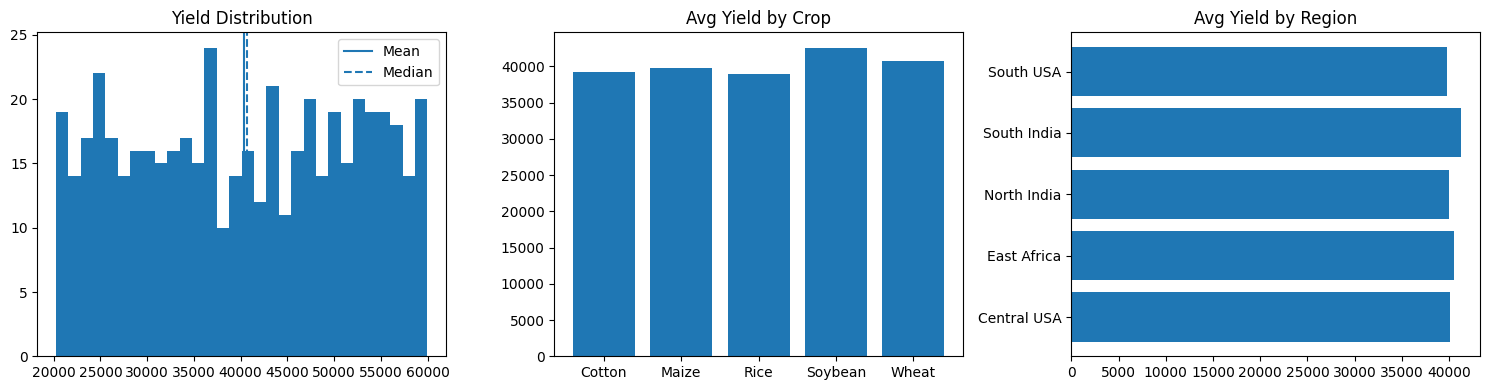

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi target
axes[0].hist(df['yield'], bins=30)
axes[0].axvline(df['yield'].mean(), linestyle='-', label='Mean')
axes[0].axvline(df['yield'].median(), linestyle='--', label='Median')
axes[0].set_title('Yield Distribution')
axes[0].legend()

# Rata-rata yield per crop
crop_yields = df.groupby('crop_type')['yield'].mean()
axes[1].bar(crop_yields.index, crop_yields.values)
axes[1].set_title('Avg Yield by Crop')

# Rata-rata yield per region
region_yields = df.groupby('region')['yield'].mean()
axes[2].barh(region_yields.index, region_yields.values)
axes[2].set_title('Avg Yield by Region')

plt.tight_layout()
plt.show()

Insight
- Distribusi yield terlihat cukup merata dengan mean dan median yang berdekatan, menandakan tidak ada skewness yang signifikan.
- Rata-rata yield antar jenis tanaman relatif mirip, namun soybean memiliki nilai tertinggi dibanding yang lain.
- Dari sisi region, South India dan East Africa menunjukkan yield yang sedikit lebih tinggi dibanding region lainnya. Secara keseluruhan, variasi antar kategori ada tetapi tidak terlalu ekstrem.

### Heatmap Correlation

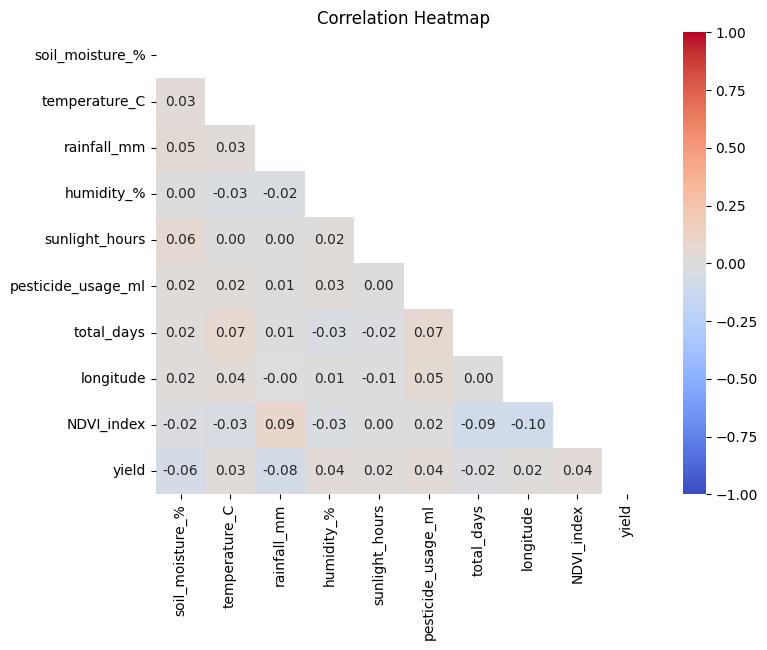

In [47]:
corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,center=0)
plt.title('Correlation Heatmap')
plt.show()

Sebagian besar korelasi antar variabel sangat lemah (mendekati 0), menunjukkan tidak ada hubungan linear yang kuat. Semua fitur juga memiliki korelasi rendah  terhadap yield sebagai target, sehingga tidak ada satu variabel yang dominan memengaruhi hasil secara langsung. Secara keseluruhan, kemungkinan hubungan antar variabel bersifat non-linear atau dipengaruhi kombinasi beberapa fitur.

### Distribution & Skewness Analysis

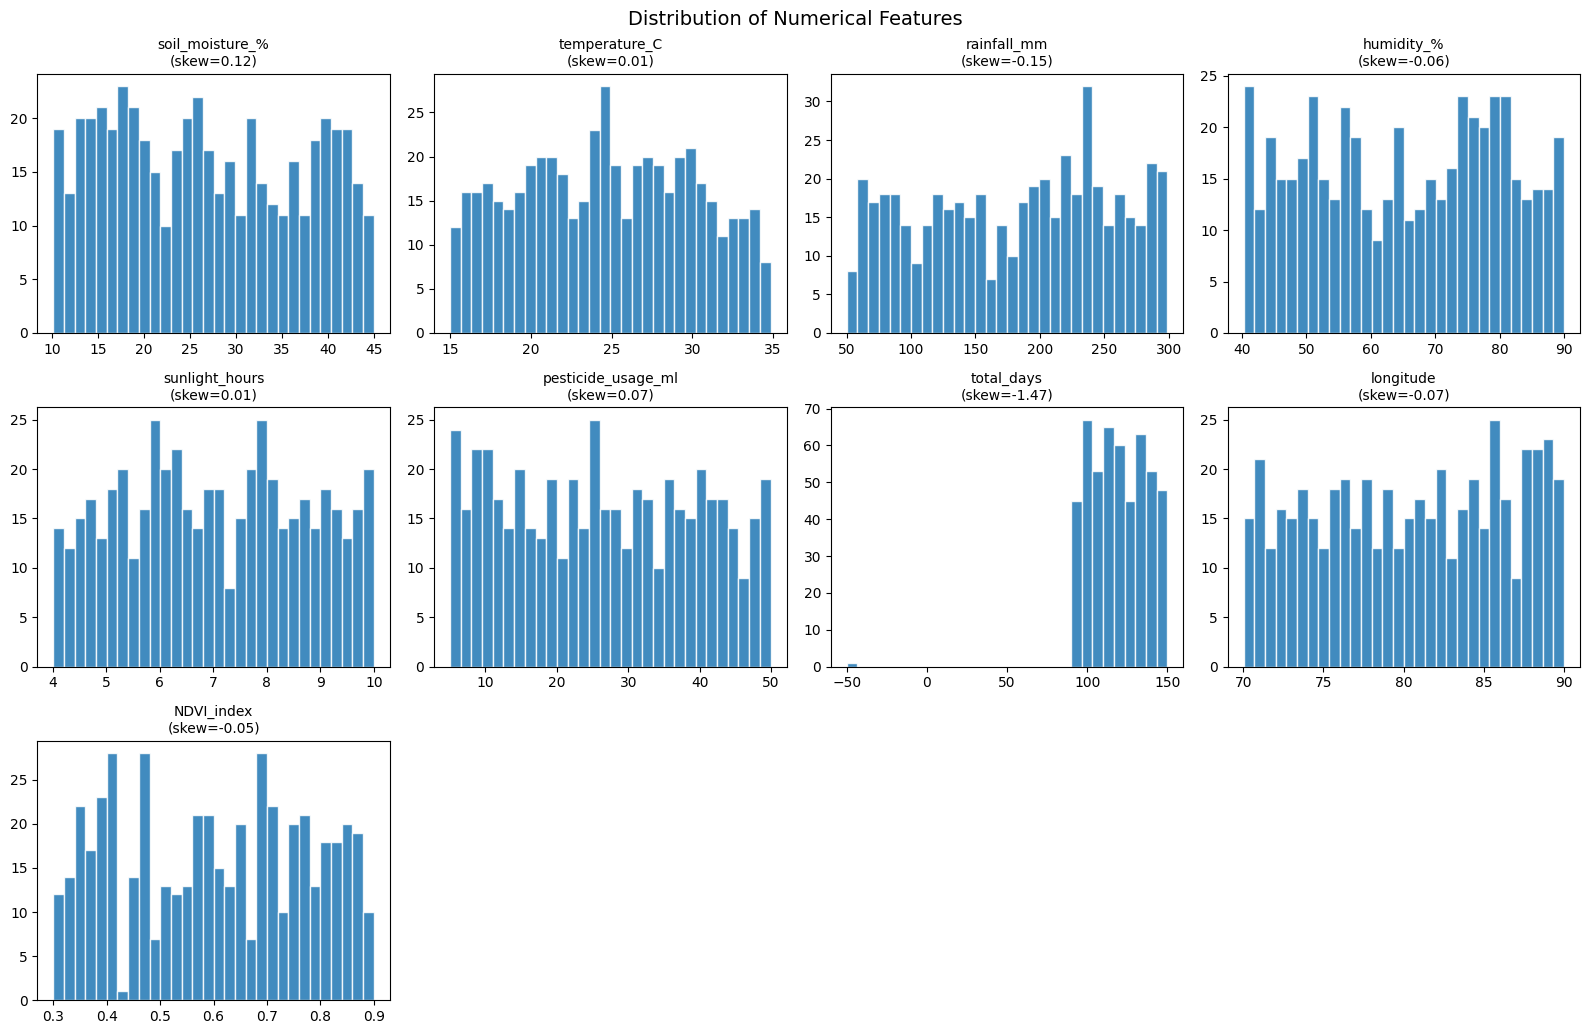

In [48]:
num_cols = df.select_dtypes(include=np.number).drop(columns=['yield'], errors='ignore').columns.tolist()
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}\n(skew={df[col].skew():.2f})', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

Sebagian besar fitur numerik memiliki distribusi yang relatif simetris (skewness mendekati 0), sehingga tidak memerlukan transformasi khusus. Namun, total_days menunjukkan skewness negatif yang cukup tinggi, mengindikasikan distribusi tidak normal kemungkinan karena adanya outlier.

### Outlier Check

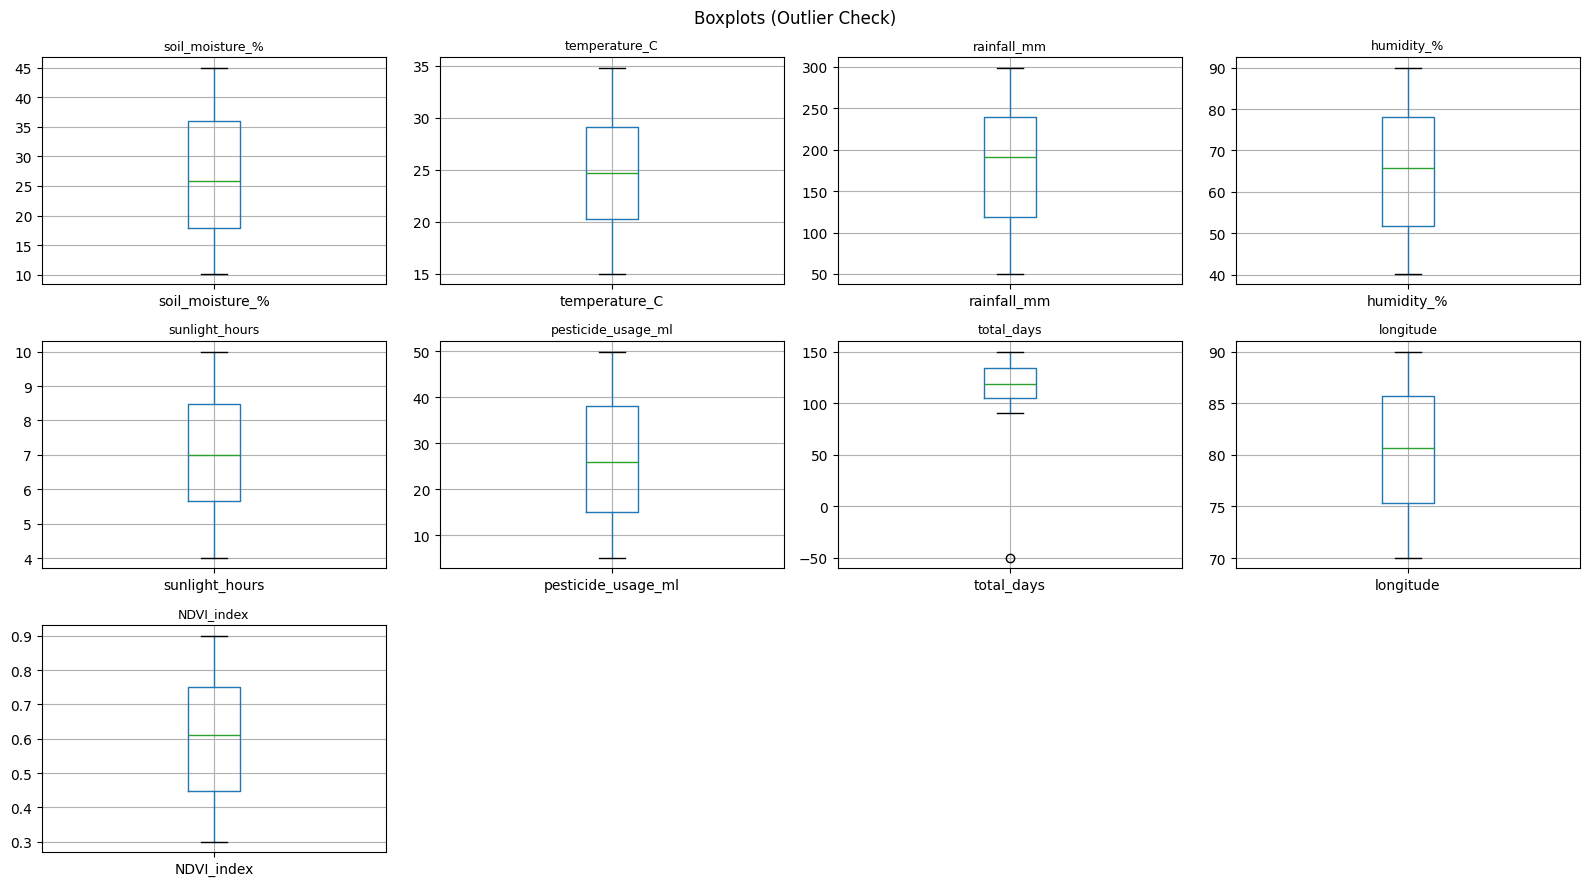

In [49]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots (Outlier Check)')
plt.tight_layout()
plt.show()

Hampir seluruh fitur numerik menunjukkan distribusi yang bersih tanpa adanya outlier, sehingga data sangat stabil dan siap digunakan untuk modeling. Satu-satunya pengecualian adalah variabel total_days yang memiliki outlier signifikan pada nilai negatif yang perlu diperbaiki atau dihapus.

### Relationship Plots

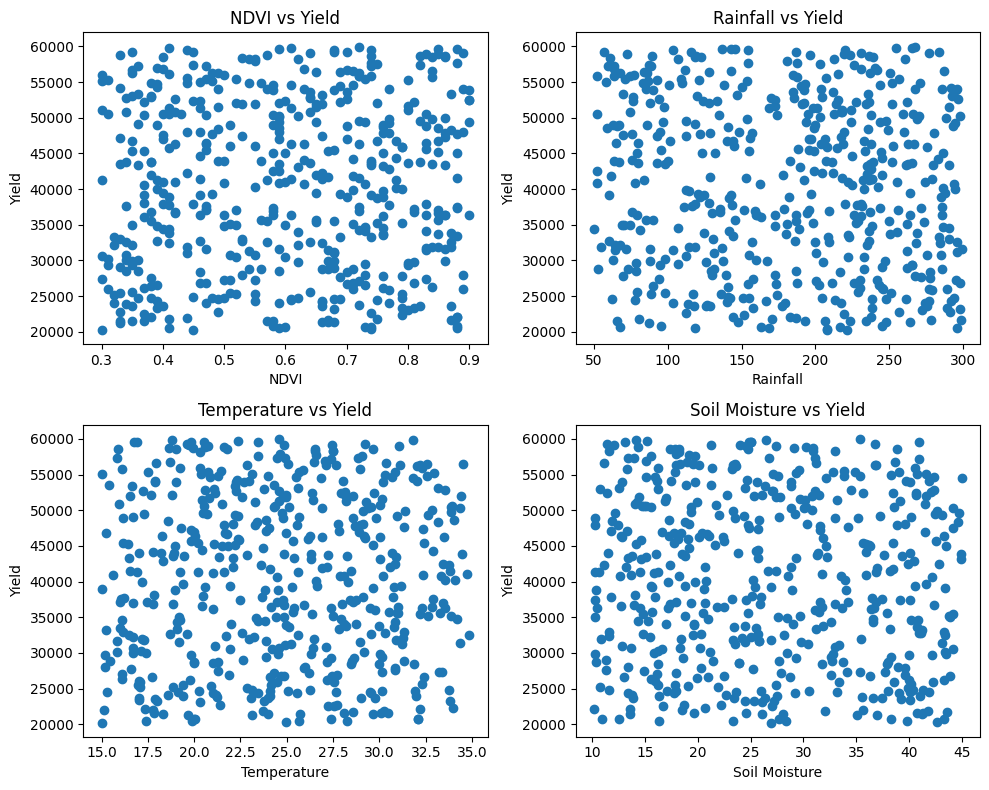

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# NDVI vs Yield
axes[0].scatter(df['NDVI_index'], df['yield'])
axes[0].set_title('NDVI vs Yield')
axes[0].set_xlabel('NDVI')
axes[0].set_ylabel('Yield')

# Rainfall vs Yield
axes[1].scatter(df['rainfall_mm'], df['yield'])
axes[1].set_title('Rainfall vs Yield')
axes[1].set_xlabel('Rainfall')
axes[1].set_ylabel('Yield')

# Temperature vs Yield
axes[2].scatter(df['temperature_C'], df['yield'])
axes[2].set_title('Temperature vs Yield')
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Yield')

# Soil Moisture vs Yield
axes[3].scatter(df['soil_moisture_%'], df['yield'])
axes[3].set_title('Soil Moisture vs Yield')
axes[3].set_xlabel('Soil Moisture')
axes[3].set_ylabel('Yield')

plt.tight_layout()
plt.show()

Keempat scatter plot menunjukkan sebaran data yang sangat acak (seperti pola awan) tanpa adanya tren linier yang jelas antara variabel independen dan Yield. Hal ini mengindikasikan bahwa baik NDVI, Rainfall, Temperature, maupun Soil Moisture tidak memiliki korelasi kuat atau hubungan langsung dengan hasil panen pada dataset tersebut. Secara keseluruhan, data ini menunjukkan bahwa hubungan antar variabel kemungkinan bersifat non-linier atau dipengaruhi oleh kombinasi faktor lain yang lebih kompleks.

# III. Preprocessing

In [51]:
df_clean = df.copy()

#### Irrelevant Data

In [52]:
# Drop kolom yang tidak relevan
df_clean = df_clean.drop(columns=['farm_id', 'sensor_id', 'timestamp', 'sowing_date', 'harvest_date'])

#### Structural Error

In [53]:
df_clean['soil_pH'] = df_clean['soil_pH'].astype(str).str.replace(',', '.').astype(float)
df_clean['latitude'] = pd.to_numeric(df_clean['latitude'], errors='coerce')

#### Missing Value

In [54]:
df_clean['irrigation_type'] = df_clean['irrigation_type'].fillna('Unknown')
df_clean['crop_disease_status'] = df_clean['crop_disease_status'].fillna('None')

- Impute 'Unknown' pada irrigation_type dilakukan karena jumlah missing value yang banyak (lebih dari 30%), sehingga penggunaan variabel global ini lebih aman daripada menghapus data atau melakukan imputasi berdasarkan Modus.
- crop_disease_status diisi 'None' berdasarkan asumsi logis bahwa ketiadaan laporan penyakit berarti tanaman tersebut memang dalam kondisi sehat.
- Kedua pendekatan ini bertujuan menjaga keutuhan dataset agar tetap bisa digunakan untuk modeling tanpa kehilangan banyak informasi penting.

#### Outlier


In [55]:
df_clean.loc[df_clean['total_days'] < 0, 'total_days'] = df_clean['total_days'].median()

In [56]:
df_clean['total_days'].describe()

,total_days
count,500.000000
mean,119.451000
std,16.770438
min,90.000000
25%,105.750000
50%,118.750000
75%,134.000000
max,150.000000


#### Split

In [57]:
X = df_clean.drop(columns=['yield'])
y = df_clean['yield']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.125, random_state=42)

print(f'\nTrain : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Val   : {X_val.shape[0]} samples  ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.1f}%)')


Train : 350 samples (70.0%)
Val   : 50 samples  (10.0%)
Test  : 100 samples  (20.0%)


#### Missing Value

In [58]:
X_train_imp = X_train.copy()
X_val_imp   = X_val.copy()
X_test_imp  = X_test.copy()

lat_median = X_train_imp.groupby('region')['latitude'].median()
sun_hours_median = X_train_imp.groupby('region')['sunlight_hours'].median()
num_medians = X_train_imp.select_dtypes(include='number').median()

for df in [X_train_imp, X_val_imp, X_test_imp]:
    df['latitude'] = df['latitude'].fillna(df['region'].map(lat_median))
    df['sunlight_hours'] = df['sunlight_hours'].fillna(df['region'].map(sun_hours_median))

Pengisian missing value dilakukan menggunakan median per wilayah karena secara geografis, nilai Latitude dan Sunlight Hours sangat bergantung pada lokasi spesifik. Dengan pendekatan ini, data yang hilang diisi dengan angka yang lebih akurat sesuai karakteristik iklim dan posisi wilayahnya masing-masing, bukan sekadar rata-rata umum yang kemungkinan bias

#### Encoding

In [59]:
cat_cols = ['region', 'crop_type', 'irrigation_type', 'fertilizer_type', 'crop_disease_status']

X_train_enc = pd.get_dummies(X_train_imp, columns=cat_cols)
X_val_enc = pd.get_dummies(X_val_imp, columns=cat_cols)
X_test_enc = pd.get_dummies(X_test_imp, columns=cat_cols)

In [60]:
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

Memastikan X_val dan X_test memiliki jumlah dan urutan kolom yang persis sama dengan X_train setelah proses encoding

#### Scaling

In [61]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train_enc)
X_val_s   = scaler.transform(X_val_enc)
X_test_s  = scaler.transform(X_test_enc)

y_train_arr = y_train.values
y_val_arr   = y_val.values
y_test_arr  = y_test.values

Dengan StandardScaler, semua fitur berada pada skala yang sama sehingga proses optimasi (seperti Gradient Descent) berjalan jauh lebih cepat dan stabil. Hal ini memastikan setiap variabel memiliki kontribusi yang adil dalam proses pelatihan model AN

# IV. Modeling

In [62]:
INPUT_DIM = X_train_enc.shape[1]
print(f'Input dimension : {INPUT_DIM}')

Input dimension : 32


## A. Baseline Model

In [63]:
baseline = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(INPUT_DIM*2, activation='relu'),
    layers.Dense(INPUT_DIM*2, activation='relu'),
    layers.Dense(1)
],name='Baseline_ANN')

baseline.compile(optimizer='adam',loss='mse',metrics=['mae'])

baseline.summary()

Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
base = baseline.fit(
    X_train_s, y_train_arr,
    validation_data=(X_val_s, y_val_arr),
    epochs=100,
    batch_size=32,
    verbose=1
)

print(f'\nTraining selesai pada epoch: {len(base.history["loss"])}')

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1798137472.0000 - mae: 40745.3672 - val_loss: 1555354112.0000 - val_mae: 37794.2070
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1798002944.0000 - mae: 40743.7031 - val_loss: 1555211904.0000 - val_mae: 37792.3555
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1797830784.0000 - mae: 40741.5781 - val_loss: 1555024256.0000 - val_mae: 37789.9141
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1797598208.0000 - mae: 40738.7031 - val_loss: 1554768896.0000 - val_mae: 37786.5938
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1797282688.0000 - mae: 40734.8125 - val_loss: 1554428672.0000 - val_mae: 37782.1797
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1796864512.0000 - mae: 40729.6562 - val_loss: 1553987840.0000 - val_mae: 37776.4492
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1796324352.0000 - mae: 40723.0039 - val_loss: 1553428608.0000 - val_mae: 37769.175

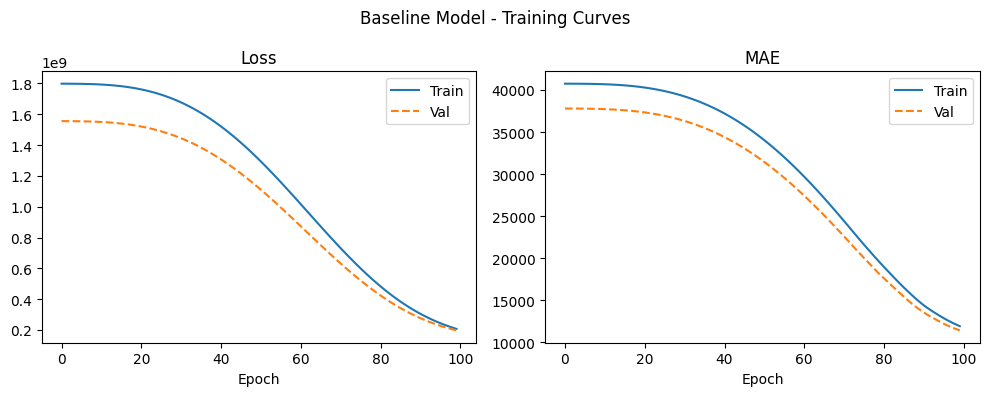

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Baseline Model - Training Curves')

# Loss
axes[0].plot(base.history['loss'], label='Train')
axes[0].plot(base.history['val_loss'], linestyle='--', label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# MAE
axes[1].plot(base.history['mae'], label='Train')
axes[1].plot(base.history['val_mae'], linestyle='--', label='Val')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

Grafik training curves tersebut menunjukkan bahwa model sedang dalam proses belajar yang cukup bagus, tetapi masih belum mencapai titik optimalnya (underfitting ringan).

- Konvergensi Positif: Baik kurva Loss maupun MAE menunjukkan tren menurun yang konsisten pada data Train dan Val, menandakan model berhasil menangkap pola data tanpa adanya indikasi overfitting (karena kedua kurva bergerak beriringan).

- Belum Mencapai Plateau: Kurva belum terlihat mendatar di akhir epoch. Ini berarti model masih memiliki potensi untuk meningkatkan akurasi jika jumlah epoch ditambah atau learning rate disesuaikan.

- Stabilitas Model: Jarak antara kurva Train dan Val yang semakin mengecil di akhir epoch menunjukkan model memiliki kemampuan generalisasi yang sangat baik terhadap data baru.

## B. Modified Model

**Alasan Modifikasi Model**

- Arsitektur  (64 → 32 → 16): Struktur ini berfungsi sebagai bottleneck untuk menangkap banyak fitur,kemudian difilter agar menjadi representasi yang lebih padat.

- Dropout (0.15): Karena dataset kecil (500 baris), dropout sangat penting untuk mencegah overfitting. (tidak digunakan di HL 3 karena fitur sudah sedikit)

- EarlyStopping (Patience 30): Ini akan menghentikan training saat model stuck (tidak membaik), dan memastikan untuk mendapatkan weight terbaik sebelum model overfit

- Learning Rate (0.0025): Penyesuaian ini mempercepat langkah model untuk mendekati solusi yang optimal.

- ReduceLROnPlateau: Fitur ini mengecilkan LR model saat mendekati titik error terenda, sehingga hasil prediksi akhir menjadi jauh lebih akurat

In [66]:
modified = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
], name='Modified_ANN')

modified.compile(optimizer=Adam(learning_rate=0.0025),loss='mse',metrics=['mae'])

modified.summary()

Model: "Modified_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
es_modified = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-5
)

mod_history = modified.fit(
    X_train_s, y_train_arr,
    validation_data=(X_val_s, y_val_arr),
    epochs=100,
    batch_size=32,
    callbacks=[es_modified, lr_scheduler],
    verbose=1
)

print(f'\nTraining selesai pada epoch: {len(mod_history.history["loss"])}')

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 1798085632.0000 - mae: 40744.7305 - val_loss: 1555233536.0000 - val_mae: 37792.5156 - learning_rate: 0.0025
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1797698560.0000 - mae: 40739.9258 - val_loss: 1554670208.0000 - val_mae: 37784.9961 - learning_rate: 0.0025
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1796828288.0000 - mae: 40729.2383 - val_loss: 1553422464.0000 - val_mae: 37768.3086 - learning_rate: 0.0025
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1794835584.0000 - mae: 40704.7812 - val_loss: 1550897280.0000 - val_mae: 37734.5742 - learning_rate: 0.0025
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1791175040.0000 - mae: 40659.7305 - val_loss: 1546020992.0000 - val_mae: 37669.3555 - learning_rate: 0.0025
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1783871616.0000 - mae: 40570.1602 - val_loss: 1537294976.0000 - val_mae: 37552.3984 - learning_rate: 0.00

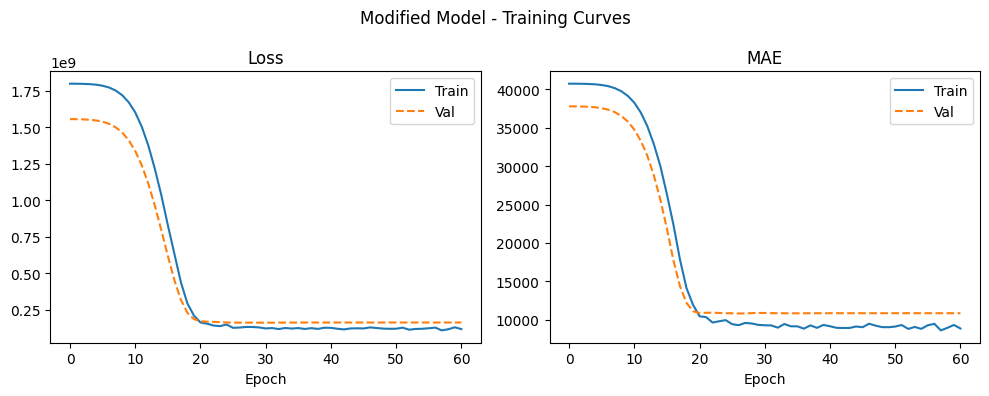

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Modified Model - Training Curves')

# Loss
axes[0].plot(mod_history.history['loss'], label='Train')
axes[0].plot(mod_history.history['val_loss'], linestyle='--', label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# MAE
axes[1].plot(mod_history.history['mae'], label='Train')
axes[1].plot(mod_history.history['val_mae'], linestyle='--', label='Val')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

Grafik ini menunjukkan performa model yang jauh lebih optimal dan efisien dibandingkan sebelumnya.

- Konvergensi Cepat: Model berhasil mencapai titik optimal (plateau) dengan sangat cepat, yakni sekitar epoch ke-20, yang menandakan arsitektur atau learning rate baru ini jauh lebih efektif.

- Good Fit: Kurva Train dan Val berhimpit sangat rapat hingga akhir, menunjukkan bahwa model memiliki kemampuan generalisasi yang sangat kuat tanpa gejala overfitting maupun underfitting.

- Stabilitas Tinggi: Setelah mencapai titik terendah, nilai Loss dan MAE tetap stabil secara konstan, membuktikan bahwa model telah menemukan bobot terbaiknya untuk melakukan prediksi yang reliabel.

# V. Evaluation

In [69]:
def evaluate_model(model, X, y, name):
    pred = model.predict(X, verbose=0).flatten()

    return {
        'Split': name,
        'MAE': mean_absolute_error(y, pred),
        'RMSE': np.sqrt(mean_squared_error(y, pred)),
        'R2': r2_score(y, pred),
        'MAPE (%)': np.mean(np.abs((y - pred) / (y + 1e-9))) * 100,
        '_pred': pred
    }

In [70]:
splits = {
    'Train': (X_train_s, y_train_arr),
    'Val':   (X_val_s, y_val_arr),
    'Test':  (X_test_s, y_test_arr)
}

base_results = {name: evaluate_model(baseline, X, y, name) for name, (X, y) in splits.items()}
mod_results  = {name: evaluate_model(modified, X, y, name) for name, (X, y) in splits.items()}

base_train, base_val, base_test = base_results.values()
mod_train, mod_val, mod_test = mod_results.values()

In [71]:
df_base_summary = pd.DataFrame(base_results).T.drop(columns=['_pred'])
df_mod_summary  = pd.DataFrame(mod_results).T.drop(columns=['_pred'])

print("Baseline ANN - Evaluation Metrics")
display(df_base_summary)

print("\nModified ANN - Evaluation Metrics")
display(df_mod_summary)

Baseline ANN - Evaluation Metrics


,Split,MAE,RMSE,R2,MAPE (%)
Train,Train,11805.229007,14236.399834,-0.469183,27.424849
Val,Val,11430.873961,14053.083532,-0.555581,27.52779
Test,Test,13765.873418,16919.780204,-1.072891,31.413333



Modified ANN - Evaluation Metrics


,Split,MAE,RMSE,R2,MAPE (%)
Train,Train,8653.79242,10183.509556,0.248255,24.106141
Val,Val,10877.220016,12666.396207,-0.263733,32.369772
Test,Test,10655.031973,12178.318961,-0.073895,28.684595


In [72]:
compare_df = pd.DataFrame({
    'Metric': ['MAE (hg/ha)', 'RMSE (hg/ha)', 'R2', 'MAPE (%)'],
    'Baseline ANN': [base_test['MAE'],base_test['RMSE'],base_test['R2'], base_test['MAPE (%)']],
    'Modified ANN': [mod_test['MAE'], mod_test['RMSE'],mod_test['R2'], mod_test['MAPE (%)']]
}).set_index('Metric')

compare_df['Better Model'] = [
    'Modified' if mod_test['MAE'] < base_test['MAE'] else 'Baseline',
    'Modified' if mod_test['RMSE'] < base_test['RMSE'] else 'Baseline',
    'Modified' if mod_test['R2'] > base_test['R2'] else 'Baseline',
    'Modified' if mod_test['MAPE (%)'] < base_test['MAPE (%)'] else 'Baseline'
]

display(compare_df)

,Baseline ANN,Modified ANN,Better Model
Metric,,,
MAE (hg/ha),13765.873418,10655.031973,Modified
RMSE (hg/ha),16919.780204,12178.318961,Modified
R2,-1.072891,-0.073895,Modified
MAPE (%),31.413333,28.684595,Modified


**Perbandingan Metrik Evaluasi**
- Peningkatan Akurasi: Modified ANN menunjukkan performa yang jauh lebih baik dengan penurunan nilai MAE dan RMSE di semua split (Train, Val, Test). Hal ini mengindikasikan bahwa modifikasi arsitektur berhasil memperkecil selisih antara hasil prediksi dengan nilai aktual.

- Perbaikan Nilai R2: Pada model Baseline, nilai R2 negatif di semua split menunjukkan model sangat buruk (bahkan lebih buruk dari rata-rata). Pada Modified ANN, nilai R2 di data Train berhasil menjadi positif (0.24), menandakan model mulai mampu menangkap pola hubungan antar variabel, meski secara keseluruhan masih tergolon sangat-sangat rendah

- Generalisasi Model: Meskipun nilai MAPE masih berada di kisaran 24-31%, Modified ANN lebih stabil dengan nilai error pada data Test yang lebih rendah dibandingkan Baseline. Ini membuktikan bahwa strategi dropout dan early stopping efektif meningkatkan kemampuan model dalam menghadapi data baru yang belum pernah dilihat sebelumnya.


**Kesimpulan:**

Rendahnya nilai metrik evaluasi ini dipicu oleh karakteristik dataset yang bersifat sintetis dan memiliki tingkat keacakan (noise) yang sangat tinggi, sehingga tidak ditemukan pola hubungan yang kuat antara fitur input dengan target. Meskipun demikian, keberhasilan model Modified ANN dalam menurunkan nilai error secara signifikan dari Baseline membuktikan bahwa arsitektur yang dirancang sudah bekerja secara optimal dalam mengekstraksi informasi yang tersedia